**TASK 1:**

In [ ]:
#I will begin with importing the dataset that needs to be cleaned and analysed
#call library required to import the csv dataset
import pandas as pd
import numpy as np

online_retail = pd.read_csv('/content/online_retail.csv')
online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
#check information about this dataset and what can we work with from there:
online_retail.isnull().sum() #we want to identify the number of empty values or not available values
online_retail.info() #to see the datatype of each variable within the dataset
#check for duplicates below
online_retail.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


np.int64(5268)

In [ ]:
#check for dulpicates
online_retail.duplicated().sum()

np.int64(5268)

In [ ]:
#how many not available or empty values do we have?
online_retail.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
#now we start cleaning:
online_retail.drop_duplicates(inplace=True)
online_retail.duplicated().sum() #check if we still have duplicates present within the set

np.int64(0)

In [ ]:
#let us convert the invoice datet to a datetime
online_retail['InvoiceDate'] = pd.to_datetime(online_retail['InvoiceDate'])
online_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
#now we want to delete the rows that do not onctain the id of customer
online_retail = online_retail.dropna(subset=['CustomerID']).copy()
online_retail["CustomerID"]= online_retail["CustomerID"].astype(int) #THIS converts it from a float to a integer
online_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [ ]:
#now we want to keep valid values wuthin a range like: So we can calculate the revenue properly
online_retail = online_retail[online_retail['Quantity'] > 0]
online_retail = online_retail[online_retail['UnitPrice'] > 0]
online_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [ ]:
#to filter out the transactions that do not ahve actual product sales:
codes_of_NOT_product_sales = ['BANK CHARGES', 'M', 'amazon','D', 'Manual', 'C2', 'DOT', 'S', 'POST']

online_retail= online_retail[~online_retail['Description'].isin(codes_of_NOT_product_sales)]
online_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [ ]:
#add a revenuecolumn which calcualted from using 2 other variables:
online_retail['REVENUE'] = online_retail['Quantity'] * online_retail['UnitPrice']

/tmp/ipykernel_4241/682372342.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  online_retail['REVENUE'] = online_retail['Quantity'] * online_retail['UnitPrice']


In [ ]:
#double check that the revenue column exist
online_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,REVENUE
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [ ]:
#we want to fill the stockCode etc via description:
desc_map = online_retail.groupby('StockCode')['Description'].agg('first').to_dict()
online_retail['Description'] = online_retail['Description'].fillna(online_retail['StockCode'].map(desc_map))
#the below is if there is anything left or drop or label
online_retail= online_retail.dropna(subset=['Description'])
online_retail

/tmp/ipykernel_4241/1747459669.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  online_retail['Description'] = online_retail['Description'].fillna(online_retail['StockCode'].map(desc_map))


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,REVENUE
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [ ]:
#now we want features for the analysis so we will implement it like this":
online_retail['InvoiceYear'] = online_retail['InvoiceDate'].dt.year
online_retail['InvoiceMonth'] = online_retail['InvoiceDate'].dt.to_period('M')
online_retail['InvoiceQuarter'] = online_retail['InvoiceDate'].dt.day
online_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,REVENUE,InvoiceYear,InvoiceMonth,InvoiceQuarter
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,2010-12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,2010-12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12,1
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20,2011,2011-12,9
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011,2011-12,9
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,2011-12,9
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,2011-12,9


In [ ]:
#we want to confirm the datasetis cleaned up before doing the dashboard
print(f"Unique customer: {online_retail['CustomerID'].nunique()}")
print(f"Unique product: {online_retail['StockCode'].nunique()}")
print(f"REVENUE SUM: {online_retail['REVENUE'].sum()}")
print(f"Date range: {online_retail["InvoiceDate"].min()} to {online_retail["InvoiceDate"].max()}") #this gives the range of dates we have within the dataset

Unique customer: 4335
Unique product: 3664
REVENUE SUM: 8833788.964000002
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [ ]:
#we will use a tuple and loop through them
#define keywords and catergory
# Define rules as (keyword, category). Order matters – put more specific keywords first.
words = [
    ('HOT WATER BOTTLE', 'Hot Water Bottles'),
    ('HOTTIE', 'Hot Water Bottles'),
    ('JUMBO BAG', 'Big Bags'),          # catch before generic "BAG"
    ('LUNCH BOX', 'Small Storage'),
    ('LUNCH BAG', 'Small Storage'),
    ('HAND WARMER', 'Gloves And Others'),
    ('UMBRELLA', 'Umbrellas'),
    ('DOORMAT', 'Doormats'),
    ('T-LIGHT', 'Light'),
    ('CANDLE', 'Light'),
    ('LANTERN', 'Lanterns'),
    ('MUG', 'Mugs And Cups'),
    ('CUP', 'Mugs And Cups'),
    ('DECORATION', 'Decoration'),
    ('ORNAMENT', 'Decoration'),
    ('CHRISTMAS', 'Decoration'),
    ('XMAS', 'Decoration'),
    ('FELTCRAFT', 'Feltcraft & Dolls'),
    ('CAKE CASE', 'Pastry Related'),
    ('BAKING SET', 'Pastry Related'),
    ('PENCIL', 'Stationery'),
    ('ERASER', 'Stationery'),
    ('PEN', 'Stationery'),
    ('BAG', 'Mini Storage'),
    ('TOTE', 'Mini Storage'),
    ('SHOPPER', 'Mini Storage'),
    ('COAT RACK', 'Homeware'),
    ('HOOK', 'Homeware'),
]

def catergorical (desc):
    desc_upper = desc.upper()
    for word, category in words:
        if word in desc_upper:
            return category
    return 'Other'

online_retail['Category'] = online_retail['Description'].apply(catergorical)
#

In [ ]:
#now we will check the peformance within regions
region_revenue = online_retail.groupby('Country')['REVENUE'].sum().sort_values(ascending=False)
region_revenue

,REVENUE
Country,
United Kingdom,7265185.704
Netherlands,285446.340
EIRE,261888.120
Germany,226382.150
France,199441.940
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


<Axes: title={'center': 'Trends of the monthly Revenue'}, xlabel='InvoiceDate'>

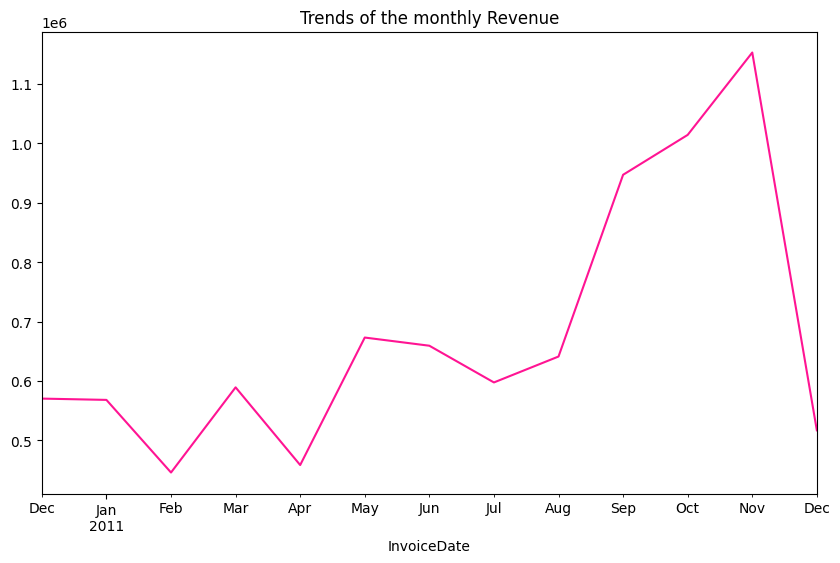

In [ ]:
#the below isto help show seasonal peak and growth or decline
revenue_for_each_month = online_retail.groupby(online_retail["InvoiceDate"].dt.to_period('M'))['REVENUE'].sum()
revenue_for_each_month.plot(kind='line', figsize=(10, 6), color='deeppink', title ='Trends of the monthly Revenue')

In [ ]:
#now we will do a bar chat for most prodcuts
product_most_sold = online_retail.groupby('Description')['REVENUE'].sum().nlargest(10)

#LET US SEE these top 10 sold products from the store
print(product_most_sold)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
RABBIT NIGHT LIGHT                     51251.24
CHILLI LIGHTS                          46265.11
Name: REVENUE, dtype: float64


<Axes: ylabel='Description'>

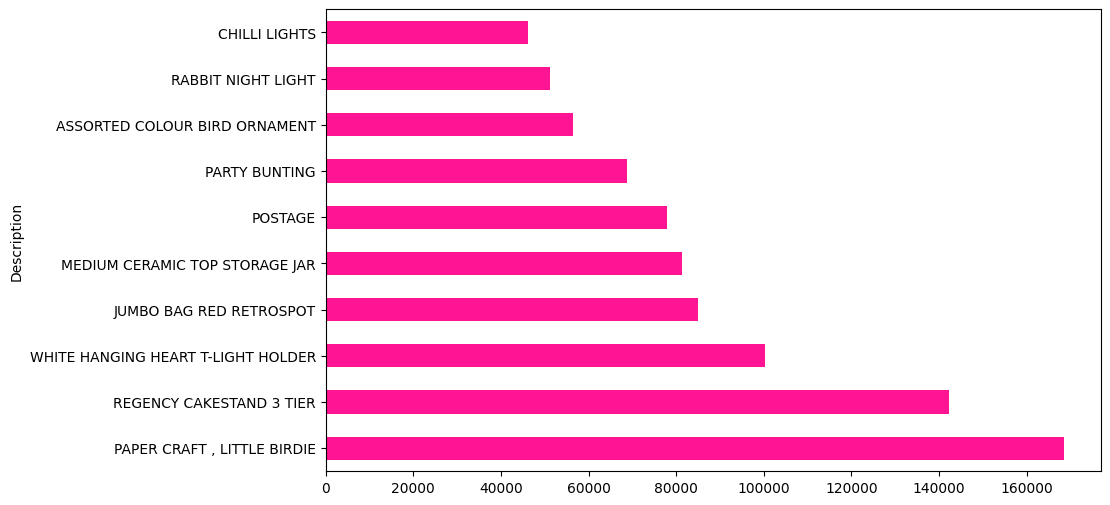

In [ ]:
#to plot the above in a a horizontal bar graph
product_most_sold.plot(kind='barh', figsize=(10, 6), color='deeppink')

In [ ]:
catergories = online_retail.groupby('Category')['REVENUE'].sum().sort_values(ascending=False)
catergories #this displays the catergories and revenue

,REVENUE
Category,
Other,5529718.554
Light,497985.880
Decoration,488256.420
Big Bags,421427.800
Small Storage,300844.890
Doormats,293996.640
Mini Storage,264461.010
Mugs And Cups,251612.320
Hot Water Bottles,204372.190


In [ ]:
online_retail.groupby('CustomerID')['REVENUE'].sum().nlargest(10)

,REVENUE
CustomerID,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,140336.83
12415,124914.53
14156,117210.08
17511,91062.38
16029,80850.84


In [ ]:
online_retail.to_csv(r'C:\Users\thula\Desktop\online_retail_cleaned.csv', index=False)

In [ ]:
online_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,REVENUE,InvoiceYear,InvoiceMonth,InvoiceQuarter,Category
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,2010-12,1,Light
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12,1,Lanterns
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,2010-12,1,Mugs And Cups
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12,1,Hot Water Bottles
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12,1,Hot Water Bottles
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20,2011,2011-12,9,Other
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011,2011-12,9,Other
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,2011-12,9,Other
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,2011-12,9,Other
